In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# 1. DOWNLOAD DATA
# use 'NVDA' (Nvidia) because it has high volatility, making trends easy to see.
# you can use other stocks or assets

ticker = 'META' 
start_date = '2020-01-01'
end_date = '2025-01-01'

def download_data(ticker, start_date, end_date):
    """Download historical price data for the specified ticker."""
    print(f"Downloading data for {ticker}...")
    try:
        df = yf.download(ticker, start=start_date, end=end_date)
        print(f"Downloaded {len(df)} rows of data for {ticker}")

        # Drop any rows with missing values to prevent errors later
        print(f"Checking for NA values...")
        df = df.dropna()
        print(f"Data filtered. {len(df)} rows of data remaining for {ticker}")



        return df
    except Exception as e:
        print(f"Error downloading data: {e}")
        return None

df = download_data(ticker, start_date, end_date)

# Check if data looks correct (Open, High, Low, Close, Volume)
print(df.head())

[*********************100%***********************]  1 of 1 completed

Downloaded 1258 rows of data for META
Checking for NA values...
Data filtered. 1258 rows of data remaining for META
Price            Close        High         Low        Open    Volume
Ticker            META        META        META        META      META
Date                                                                
2020-01-02  208.324783  208.334709  204.839137  205.315803  12077100
2020-01-03  207.222458  208.940453  205.514388  205.772594  11188400
2020-01-06  211.125198  211.303942  205.087374  205.266118  17058900
2020-01-07  211.582031  213.091491  210.281121  211.343706  14912400
2020-01-08  213.727051  214.739979  211.135155  211.522449  13475000


In [3]:
# 2. IMPLEMENT STRATEGY
# Calculate Moving Averages
df['SMA_20'] = df['Close'].rolling(window=20).mean()
df['SMA_50'] = df['Close'].rolling(window=50).mean()

# Create Signals (1 = Buy, 0 = Sell/Cash)
df['Signal'] = np.where(df['SMA_20'] > df['SMA_50'], 1.0, 0.0)

# CRITICAL STEP: Create 'Position'
# Shift the signal by 1 day. 
# Why? We calculate the signal using Today's Close price. 
# We can only buy at Tomorrow's Open. If we don't shift, it's "Look-ahead Bias" (cheating).
df['Position'] = df['Signal'].shift(1)

print("Strategy indicators created.")
df.to_csv("strategy.csv")
print(df.tail(5))

Strategy indicators created.
Price            Close        High         Low        Open   Volume  \
Ticker            META        META        META        META     META   
Date                                                                  
2024-12-24  605.839600  606.078835  597.396253  600.825382  4726100   
2024-12-26  601.453430  604.394169  597.057319  603.576740  6081400   
2024-12-27  597.924500  599.958065  587.945956  597.525733  8084200   
2024-12-30  589.381409  595.063503  583.739228  586.899246  7025900   
2024-12-31  583.669495  592.102862  582.014679  590.408255  6019500   

Price           SMA_20      SMA_50 Signal Position  
Ticker                                              
Date                                                
2024-12-24  603.579889  584.275632    1.0      1.0  
2024-12-26  605.088748  584.625580    1.0      1.0  
2024-12-27  606.637299  585.093801    1.0      1.0  
2024-12-30  607.503708  585.388372    1.0      1.0  
2024-12-31  607.162671  585.577

In [4]:
# 3. CALCULATE RETURNS
# Calculate daily percent change of the stock (Buy and Hold strategy)
df['Market_Return'] = df['Close'].pct_change()

# Calculate Strategy Returns
# If Position was 1 yesterday, we get the Market_Return today.
# If Position was 0, we get 0 return.
df['Strategy_Return'] = df['Position'] * df['Market_Return']

# 4. CALCULATE METRICS
# Cumulative Returns (for plotting)
df['Cumulative_Market_Return'] = (1 + df['Market_Return']).cumprod()
df['Cumulative_Strategy_Return'] = (1 + df['Strategy_Return']).cumprod()

# Sharpe Ratio (Risk-Adjusted Return)
# Assume 252 trading days in a year. 
sharpe_ratio = (df['Strategy_Return'].mean() / df['Strategy_Return'].std()) * np.sqrt(252)

# Max Drawdown (Worst loss from a peak)
# Calculate running maximum
running_max = df['Cumulative_Strategy_Return'].cummax()
drawdown = (df['Cumulative_Strategy_Return'] / running_max) - 1
max_drawdown = drawdown.min()

print(f"--- Performance Metrics for {ticker} ---")
print(f"Total Market Return: {df['Cumulative_Market_Return'].iloc[-1]:.2f}x")
print(f"Total Strategy Return: {df['Cumulative_Strategy_Return'].iloc[-1]:.2f}x")
print(f"Sharpe Ratio: {sharpe_ratio:.2f}")
print(f"Max Drawdown: {max_drawdown:.2%}")

--- Performance Metrics for META ---
Total Market Return: 2.80x
Total Strategy Return: 4.44x
Sharpe Ratio: 1.12
Max Drawdown: -34.48%


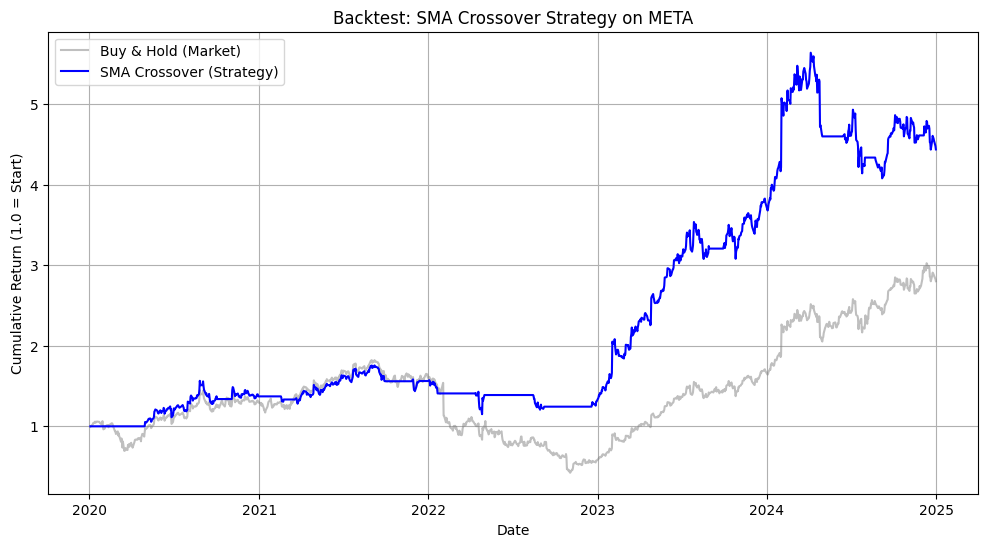

In [5]:
# 5. VISUALIZE
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['Cumulative_Market_Return'], label='Buy & Hold (Market)', color='gray', alpha=0.5)
plt.plot(df.index, df['Cumulative_Strategy_Return'], label='SMA Crossover (Strategy)', color='blue')

plt.title(f'Backtest: SMA Crossover Strategy on {ticker}')
plt.xlabel('Date')
plt.ylabel('Cumulative Return (1.0 = Start)')
plt.legend()
plt.grid(True)
plt.show()